In [ ]:

# Install required libraries (if not installed)
!pip install tensorflow pandas scikit-learn seaborn matplotlib

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:

from google.colab import files

# This will trigger a button for you to select your JSON file
uploaded = files.upload()

# Confirm that the file is loaded
if uploaded:
    file_name = list(uploaded.keys())[0]
    print(f"Successfully uploaded: {file_name}")
else:
    print("No file was uploaded.")

Saving Autism.csv to Autism.csv
Successfully uploaded: Autism.csv


In [ ]:

import json
import pandas as pd
import os

# Get uploaded file name
file_name = list(uploaded.keys())[0]
file_ext = os.path.splitext(file_name)[1].lower()

print(f"Detected file type: {file_ext}")

# 1. Logic for CSV files (like your sales data)
if file_ext == '.csv':
    df = pd.read_csv(file_name)
    print("CSV loaded successfully.")

# 2. Logic for JSON files (like your metadata/text datasets)
elif file_ext == '.json':
    with open(file_name, "r") as f:
        data = json.load(f)

    if isinstance(data, list):
        df = pd.json_normalize(data)
    elif isinstance(data, dict):
        list_key = [k for k, v in data.items() if isinstance(v, list)]
        if list_key:
            print(f"Extracting data from key: '{list_key[0]}'")
            df = pd.json_normalize(data, record_path=[list_key[0]])
        else:
            df = pd.json_normalize(data)
    print("JSON flattened successfully.")

else:
    print("Unsupported file format.")

# 3. CRITICAL CHECK for any file type
print("--- Verification ---")
print(f"Dataset shape: {df.shape}")
if df.shape[0] <= 1:
    print("WARNING: Only 1 row detected. Check if your data is hidden inside a specific JSON key.")
else:
    print("SUCCESS: Data is loaded and ready for preprocessing.")

df.head()

Detected file type: .csv
CSV loaded successfully.
--- Verification ---
Dataset shape: (704, 21)
SUCCESS: Data is loaded and ready for preprocessing.


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Automatically select target column (last column)
target_column = df.columns[-1]
print("Detected target column:", target_column)

# Separate features and target
X = df.drop(target_column, axis=1)
y = df[target_column]

# Encode target if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Convert categorical features in X to numeric
X = pd.get_dummies(X)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing complete. Feature shape:", X_train.shape)

Detected target column: Class/ASD
Preprocessing complete. Feature shape: (563, 152)


In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

model.fit(X_train, y_train, epochs=50, batch_size=8)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         9,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7265 - loss: 0.5445
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9059 - loss: 0.2750
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9449 - loss: 0.1621
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9787 - loss: 0.0826
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9876 - loss: 0.0561
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9911 - loss: 0.0403
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9876 - loss: 0.0308
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9840 - loss: 0.0383
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9947 - loss: 0.0212
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9947 - loss: 0.0234
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9982 - loss: 0.0105
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9964 - lo

In [ ]:

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


Accuracy: 0.9432624113475178
[[101   4]
 [  4  32]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       105
           1       0.89      0.89      0.89        36

    accuracy                           0.94       141
   macro avg       0.93      0.93      0.93       141
weighted avg       0.94      0.94      0.94       141



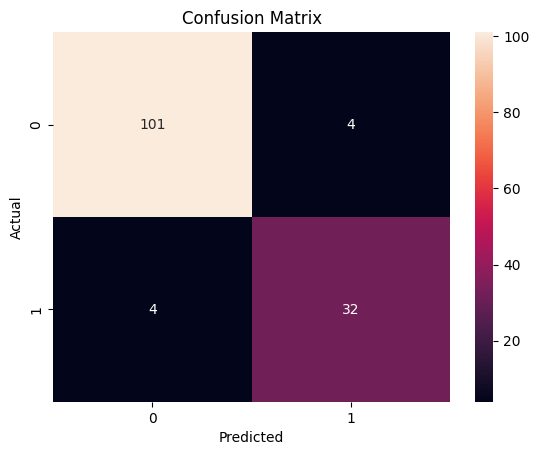

In [ ]:

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()